In [ ]:
import shap
import joblib
import pandas as pd
import json
import numpy as np


In [4]:
# Load trained IDS model
model = joblib.load("../models/trained_models/rf_ids_model.pkl")

# Load label encoder
label_encoder = joblib.load("../models/label_encoder.pkl")

# Load feature list
with open("../features/feature_list.json") as f:
    feature_cols = json.load(f)

print("Model, encoder, and feature list loaded.")
print("Number of features:", len(feature_cols))


Model, encoder, and feature list loaded.
Number of features: 78


In [6]:
df = pd.read_csv("../data/processed/cicids2017_processed.csv")

X = df[feature_cols]
y = df["Attack_Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (2830743, 78)
y shape: (2830743,)


In [7]:
background = X.sample(n=1000, random_state=42)


In [8]:
explainer = shap.TreeExplainer(
    model,
    data=background,
    feature_perturbation="interventional"
)

print("SHAP TreeExplainer initialized.")


SHAP TreeExplainer initialized.


In [9]:
benign_label = label_encoder.transform(["BENIGN"])[0]

sample = (
    X[y == benign_label]
    .sample(n=1, random_state=7)
    .reset_index(drop=True)
)


In [10]:
pred = model.predict(sample)[0]
print("Predicted class:", label_encoder.inverse_transform([pred])[0])


Predicted class: BENIGN


In [11]:
shap_values = explainer(sample)

print("SHAP values shape:", shap_values.values.shape)


SHAP values shape: (1, 78, 9)


In [10]:
pred_class = pred  # BENIGN = 0

shap_vals = shap_values.values[0, :, pred_class]

exp = shap.Explanation(
    values=shap_vals,
    base_values=shap_values.base_values[0, pred_class],
    data=sample.iloc[0],
    feature_names=sample.columns
)


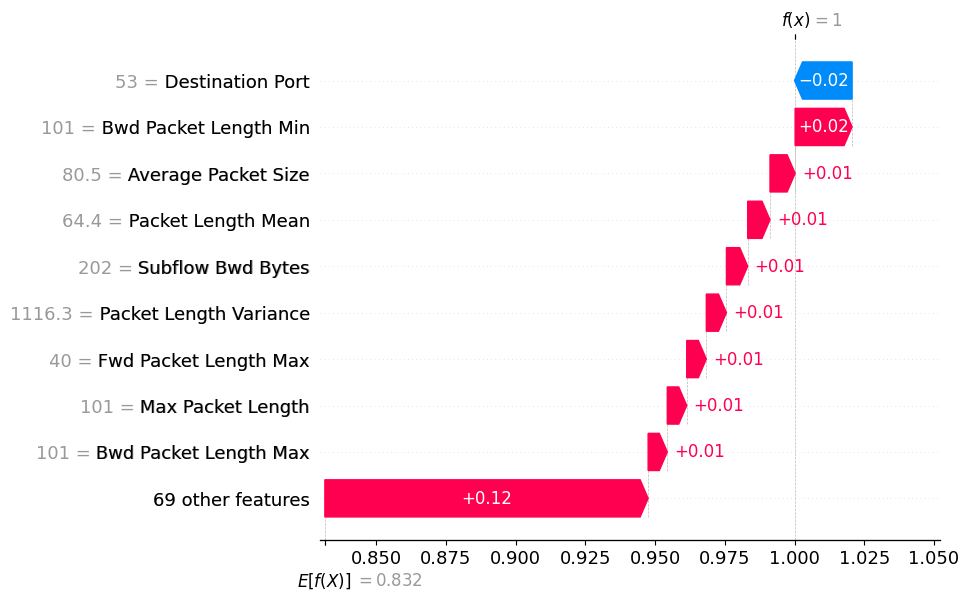

In [11]:
shap.plots.waterfall(exp)


In [12]:
# Get encoded DoS label
dos_label = label_encoder.transform(["DoS"])[0]

# Select one real DoS sample
dos_sample = (
    X[y == dos_label]
    .sample(n=1, random_state=21)
    .reset_index(drop=True)
)


In [13]:
pred = model.predict(dos_sample)[0]
print("Predicted class:", label_encoder.inverse_transform([pred])[0])


Predicted class: DoS


In [14]:
shap_values = explainer(dos_sample)

print("SHAP values shape:", shap_values.values.shape)


SHAP values shape: (1, 78, 9)


In [15]:
pred_class = pred  # DoS

shap_vals_dos = shap_values.values[0, :, pred_class]

exp_dos = shap.Explanation(
    values=shap_vals_dos,
    base_values=shap_values.base_values[0, pred_class],
    data=dos_sample.iloc[0],
    feature_names=dos_sample.columns
)


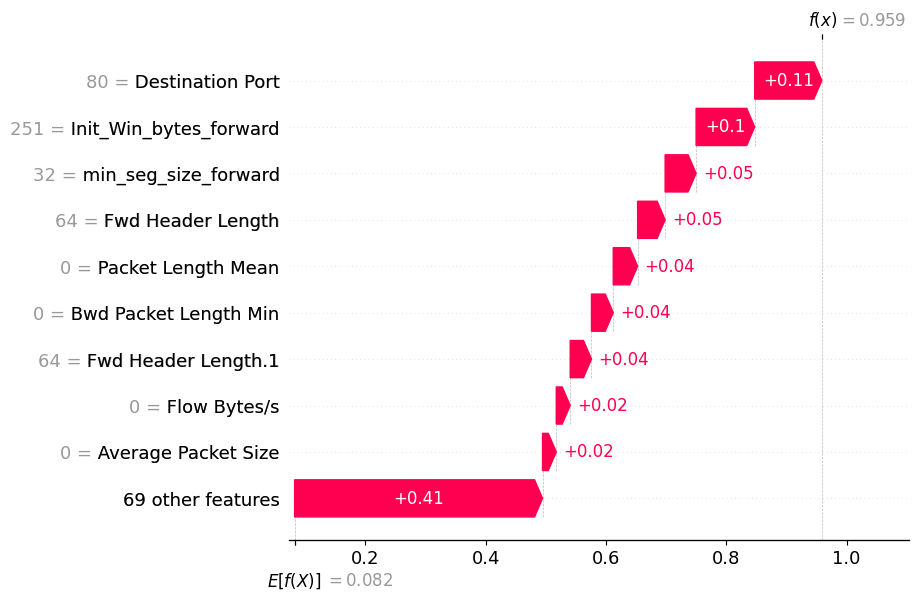

In [16]:
shap.plots.waterfall(exp_dos)


In [14]:
#bruteforce
bf_label = label_encoder.transform(["BruteForce"])[0]

bf_profile = df[df["Attack_Label"] == bf_label][feature_cols].median()

np.random.seed(42)

synthetic_bf = bf_profile.copy()

synthetic_bf["Destination Port"] = 22
synthetic_bf["Flow Duration"] *= 0.3
synthetic_bf["Total Fwd Packets"] *= 2.5
synthetic_bf["Total Backward Packets"] *= 1.5
synthetic_bf["Flow Packets/s"] *= 3.0
synthetic_bf["Fwd Packets/s"] *= 3.0
synthetic_bf["PSH Flag Count"] *= 2.0
synthetic_bf["ACK Flag Count"] *= 2.0
synthetic_bf["Idle Mean"] *= 0.1
synthetic_bf["Idle Std"] *= 0.1

for col in synthetic_bf.index:
    if col not in [
        "Destination Port", "Flow Duration",
        "Total Fwd Packets", "Total Backward Packets",
        "Flow Packets/s", "Fwd Packets/s",
        "PSH Flag Count", "ACK Flag Count",
        "Idle Mean", "Idle Std"
    ]:
        synthetic_bf[col] *= np.random.uniform(0.9, 1.1)

X_synthetic_bf = pd.DataFrame([synthetic_bf])

In [15]:
pred = model.predict(X_synthetic_bf)[0]
print("Predicted class:", label_encoder.inverse_transform([pred])[0])

Predicted class: BruteForce


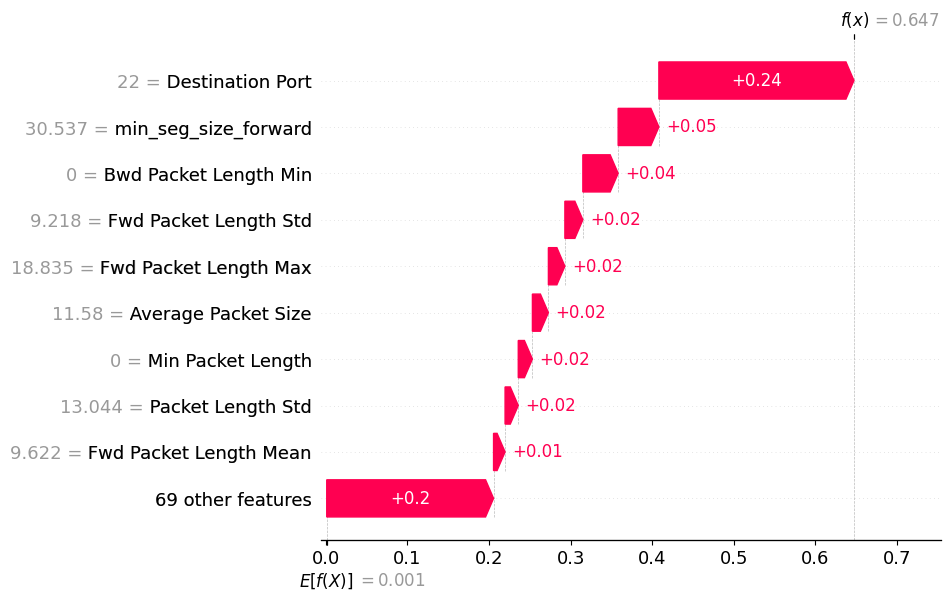

In [16]:
shap_values = explainer(X_synthetic_bf)

pred_class = pred

shap_vals_bf = shap_values.values[0, :, pred_class]

exp_bf = shap.Explanation(
    values=shap_vals_bf,
    base_values=shap_values.base_values[0, pred_class],
    data=X_synthetic_bf.iloc[0],
    feature_names=X_synthetic_bf.columns
)

shap.plots.waterfall(exp_bf)

In [17]:
#global explanation
X_sample = X.sample(n=2000, random_state=42)

In [18]:
shap_values_global = explainer(X_sample)

100%|===================| 17966/18000 [06:44<00:00]        

In [19]:
print(shap_values_global.values.shape)



(2000, 78, 9)


In [20]:
import numpy as np

# Mean absolute SHAP across samples and classes
mean_shap = np.mean(np.abs(shap_values_global.values), axis=(0, 2))

feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": mean_shap
}).sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
0,Destination Port,0.008320
11,Bwd Packet Length Min,0.004458
67,Init_Win_bytes_backward,0.003939
66,Init_Win_bytes_forward,0.003690
69,min_seg_size_forward,0.003535
46,PSH Flag Count,0.003194
6,Fwd Packet Length Max,0.003096
4,Total Length of Fwd Packets,0.002873
52,Average Packet Size,0.002855
65,Subflow Bwd Bytes,0.002848


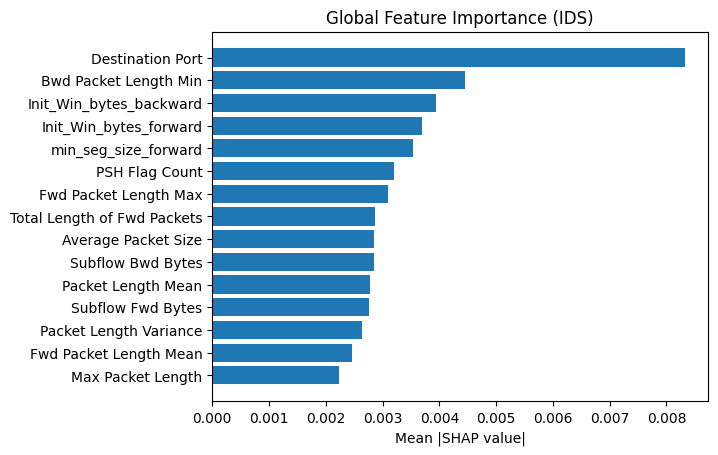

In [21]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure()
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.xlabel("Mean |SHAP value|")
plt.title("Global Feature Importance (IDS)")
plt.show()

In [22]:
#DoS Global SHAP
dos_label = label_encoder.transform(["DoS"])[0]

dos_shap = np.mean(
    np.abs(shap_values_global.values[:, :, dos_label]),
    axis=0
)

dos_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": dos_shap
}).sort_values(by="Importance", ascending=False)

dos_importance.head(10)

,Feature,Importance
0,Destination Port,0.022901
67,Init_Win_bytes_backward,0.013087
11,Bwd Packet Length Min,0.011053
66,Init_Win_bytes_forward,0.008308
69,min_seg_size_forward,0.007387
6,Fwd Packet Length Max,0.007150
13,Bwd Packet Length Std,0.006559
65,Subflow Bwd Bytes,0.006111
52,Average Packet Size,0.005807
40,Packet Length Mean,0.005299


In [23]:
bf_label = label_encoder.transform(["BruteForce"])[0]

bf_shap = np.mean(
    np.abs(shap_values_global.values[:, :, bf_label]),
    axis=0
)

bf_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": bf_shap
}).sort_values(by="Importance", ascending=False)

bf_importance.head(10)

,Feature,Importance
0,Destination Port,0.002676
11,Bwd Packet Length Min,0.002071
69,min_seg_size_forward,0.002042
63,Subflow Fwd Bytes,0.001228
6,Fwd Packet Length Max,0.000975
18,Flow IAT Max,0.000973
53,Avg Fwd Segment Size,0.000939
35,Bwd Header Length,0.000871
40,Packet Length Mean,0.000817
54,Avg Bwd Segment Size,0.000801


In [24]:
#SHAP Summary (Beeswarm) Plot
#overall multiclass summary
# shap_values_global already computed earlier
# shape: (2000, 78, 9)

# Mean across classes
shap_mean_across_classes = np.mean(
    shap_values_global.values,
    axis=2
)

In [25]:
print(shap_mean_across_classes.shape)

(2000, 78)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_16052\1415823195.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


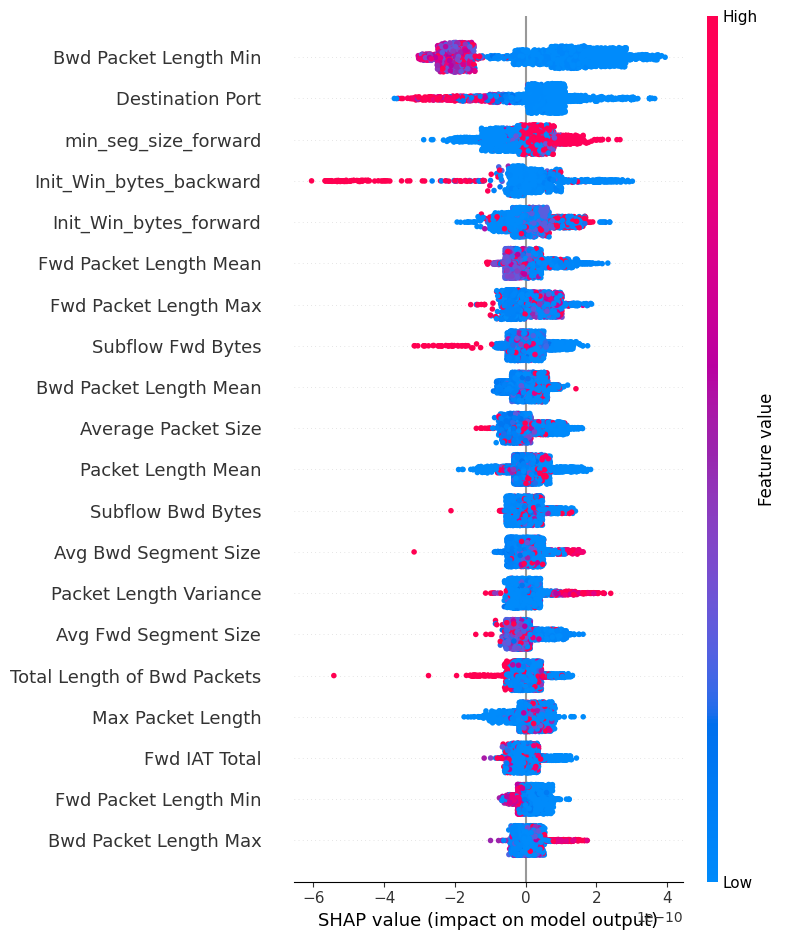

In [26]:
import shap

shap.summary_plot(
    shap_mean_across_classes,
    X_sample,
    plot_type="dot",
    show=True
)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16052\3922673902.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


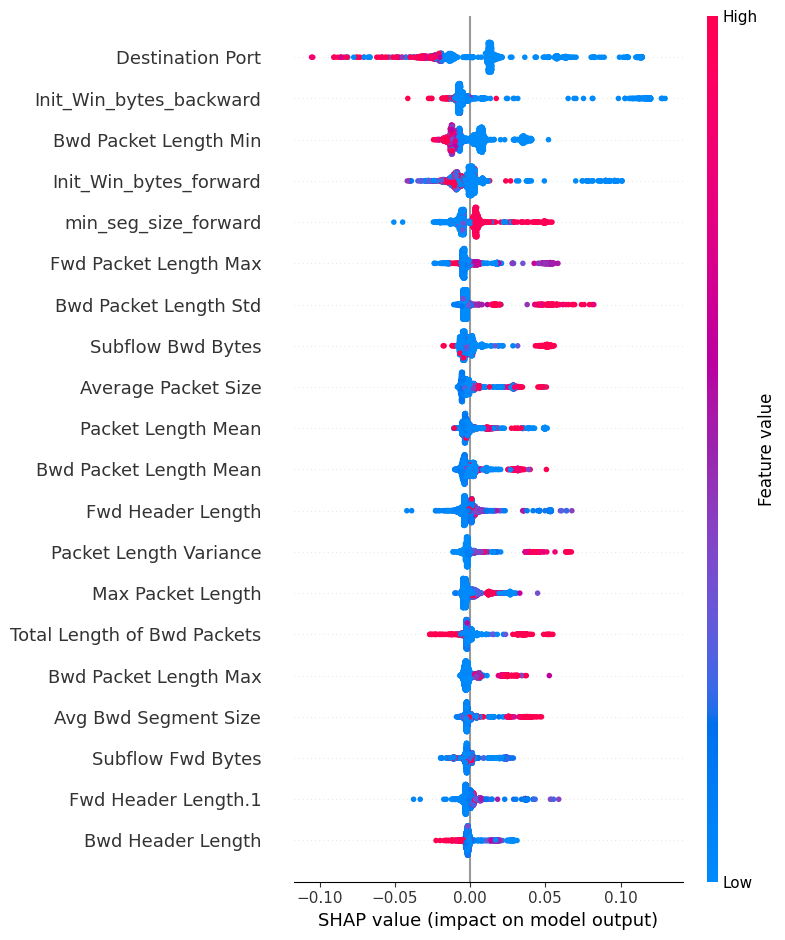

In [27]:
#class specific summary
#DoS beeswarm
dos_label = label_encoder.transform(["DoS"])[0]

shap_dos = shap_values_global.values[:, :, dos_label]

shap.summary_plot(
    shap_dos,
    X_sample,
    plot_type="dot",
    show=True
)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16052\3278401342.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


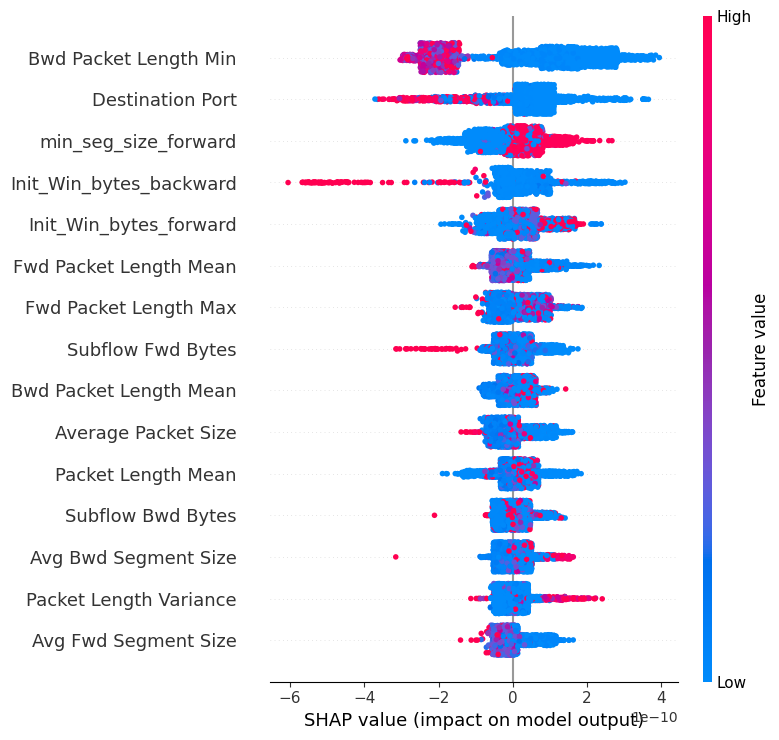

In [28]:
shap.summary_plot(
    shap_mean_across_classes,
    X_sample,
    max_display=15
)